#  PyTorch Lightning. Разворачивание веб-сервера для использования моделей.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://lightning.ai/docs/pytorch/stable/starter/introduction.html
* https://lightning.ai/docs/pytorch/stable/levels/core_skills.html
* https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.log
* https://lightning.ai/docs/pytorch/stable/extensions/logging.html
* https://lightning.ai/docs/pytorch/stable/common/progress_bar.html
* https://lightning.ai/docs/pytorch/stable/common/early_stopping.html
* https://lightning.ai/docs/pytorch/1.6.3/api/pytorch_lightning.utilities.model_summary.html#pytorch_lightning.utilities.model_summary.ModelSummary
* https://torchmetrics.readthedocs.io/en/stable/pages/lightning.html
* https://pykit.org/how-to-run-python-flask-app-online-using-ngrok/

## Задачи для совместного разбора

1\. Создайте датасет для регрессии и обучите модель при помощи PyTorch Lightning.

## Задачи для самостоятельного решения

In [12]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.multiprocessing as mp
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.classification import Accuracy
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from PIL import Image
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torchmetrics
import numpy as np
import tqdm

In [13]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch version: 2.5.0+cu124
CUDA available: True
CUDA version: 12.4
Number of GPUs: 2
GPU 0: NVIDIA GeForce RTX 4090
GPU 1: NVIDIA GeForce RTX 4090


In [14]:
torch.cuda.set_device(0)
print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: NVIDIA GeForce RTX 4090


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


<p class="task" id="1"></p>

1\. Опишите датасет `AnimalDetectionDataset` на основе архива `animals.zip`. Реализуйте `__getitem__` таким образом, чтобы он возвращал три элемента: тензор с изображением, словарь с координатами bounding box и метку объекта. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений, преобразование для метки объекта (для кодирования) и флаг, показывающий, нужно ли возвращать исходные или нормированные координаты bounding box.  Разбейте набор данных на обучающее и валидационное множество. При создании датасета не забудьте указать преобразования, соответствующие модели ResNet.

- [ ] Проверено на семинаре

In [16]:
class AnimalDetectionDataset(Dataset):
    def __init__(self, root_dir, transforms=None, label_transforms=None, normalize_bboxes=True):
        self.root_dir = root_dir
        self.transforms = transforms
        self.label_transforms = label_transforms
        self.normalize_bboxes = normalize_bboxes

        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]
        self.xml_files = [f.replace('.jpg', '.xml') for f in self.image_files]

        print(f"Found {len(self.image_files)} image files.")
        print(f"Found {len(self.xml_files)} XML files.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert("RGB")

        xml_name = os.path.join(self.root_dir, self.xml_files[idx])

        if not os.path.exists(xml_name):
            print(f"Error: XML файл не найден по пути: {xml_name}")
            return None  

        try:
            tree = ET.parse(xml_name)
            root = tree.getroot()  
        except Exception as e:
            print(f"Error: Не удалось обработать XML файл {xml_name}. Ошибка: {e}")
            return None

        bndbox = root.find('.//bndbox')
        if bndbox is not None:
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
        else:   
            xmin = ymin = xmax = ymax = 0.0  

        label = root.find('.//name').text
        label = 0 if label == 'cat' else 1

        bbox = torch.tensor([xmin, ymin, xmax, ymax], dtype=torch.float32)
        if self.normalize_bboxes:
            width, height = image.size
            bbox = bbox / torch.tensor([width, height, width, height], dtype=torch.float32)

        if self.transforms:
            image = self.transforms(image)

        if self.label_transforms:
            label = self.label_transforms(label)

        return image, {'bbox': bbox, 'label': label}


In [17]:
root_dir = 'C:\\Users\\n.sedov\\Documents\\vscode docs\\ITiABD-PM22-7-Nikolay-Sedov\\DL\\Asirra_ cat vs dogs'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = AnimalDetectionDataset(root_dir, transforms=transform)

Found 1100 image files.
Found 1100 XML files.


In [18]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size 
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [19]:
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
mp.set_start_method('spawn', force=True)

<p class="task" id="2"></p>

2\. Напишите модель для решения задачи выделения объектов в виде объекта `lightning.LightningModule`. Реализуйте двухголовую сеть, одна голова которой предсказывает метку объекта (задача классификации), а вторая голова предсказывает 4 координаты вершин bounding box (задача регрессии). В качестве backbone используйте модель resnet50 из пакета `torchvision`. В качестве функции потерь используйте сумму MSELoss (для расчета ошибки на задаче регрессии) и CrossEntropyLoss (для расчета ошибки на задачи классификации). 

Реализуйте следующий функционал при помощи `lightning` и `torchmetrics`:
* для каждого батча во время обучения рассчитывается значение функции потерь и точности прогнозов, по завершению эпохи метрики усредняются;
* для каждого батча во время валидации рассчитывается значение функции потерь и точности прогнозов, по завершению эпохи метрики усредняются;
* если значение функции потерь не улучшалось в течении 5 эпох, происходит ранняя остановка;
* при создании модель на экран выводится сводка по модели с указанием размерностей выходов слоев;
* для визуализации процесса обучения используется tensorboard.

Используя обученную модель, получите предсказания для изображения кошки и собаки и отрисуйте их. Выполните процедуру, обратную нормализации, чтобы корректно отобразить фотографии.

- [ ] Проверено на семинаре

In [20]:
class ObjectDetectionModel(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-4):
        super(ObjectDetectionModel, self).__init__()

        self.backbone = models.resnet50(weights="IMAGENET1K_V1")
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classification_head = nn.Linear(in_features, num_classes)
        self.regression_head = nn.Linear(in_features, 4)
        self.acc_metric = Accuracy(task="multiclass", num_classes=num_classes)
        self.mAP_metric = MeanAveragePrecision()
        self.writer = SummaryWriter(log_dir='logs')
        self.lr = lr

    def train_dataloader(self):
        return train_loader

    def val_dataloader(self):
        return val_loader

    def forward(self, x):
        x = self.backbone(x)
        class_preds = self.classification_head(x)
        bbox_preds = self.regression_head(x)
        return class_preds, bbox_preds

    def training_step(self, batch, batch_idx):
        images, targets = batch
        class_preds, bbox_preds = self(images)
        labels = targets['label']
        bboxes = targets['bbox']
        classification_loss = F.cross_entropy(class_preds, labels)
        bbox_loss = F.mse_loss(bbox_preds, bboxes)
        total_loss = classification_loss + bbox_loss
        acc = self.acc_metric(class_preds.softmax(dim=-1), labels)
        self.log("train_loss", total_loss)
        self.log("train_acc", acc, on_epoch=True)
        self.writer.add_scalar('Loss/train', total_loss, self.current_epoch)
        self.writer.add_scalar('Accuracy/train', acc, self.current_epoch)
        return total_loss

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        class_preds, bbox_preds = self(images)
        labels = targets['label']
        bboxes = targets['bbox']
        classification_loss = F.cross_entropy(class_preds, labels)
        bbox_loss = F.mse_loss(bbox_preds, bboxes)
        total_loss = classification_loss + bbox_loss
        acc = self.acc_metric(class_preds.softmax(dim=-1), labels)
        self.log("val_loss", total_loss)
        self.log("val_acc", acc, on_epoch=True)
        self.writer.add_scalar('Loss/val', total_loss, self.current_epoch)
        self.writer.add_scalar('Accuracy/val', acc, self.current_epoch)
        pred_scores = class_preds.softmax(dim=-1).detach().cpu()
        pred_boxes = bbox_preds.detach().cpu()
        pred_labels = pred_scores.argmax(axis=-1)
        pred = [{
            "boxes": pred_boxes,
            "scores": pred_scores.max(dim=-1).values,
            "labels": pred_labels
        }]
        target = [{
            "boxes": bboxes.detach().cpu(),
            "labels": labels.detach().cpu()
        }]
        self.mAP_metric.update(pred, target)
        return total_loss

    def on_validation_epoch_end(self):
        mAP = self.mAP_metric.compute()
        mAP_value = mAP["map"].item() if isinstance(mAP, dict) else mAP.item()
        self.log("val_mAP", mAP_value)
        self.writer.add_scalar('mAP/val', mAP_value, self.current_epoch)
        self.mAP_metric.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

    def on_fit_start(self):
        print(self)

    def configure_callbacks(self):
        early_stop_callback = pl.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, mode="min", verbose=True
        )
        checkpoint_callback = pl.callbacks.ModelCheckpoint(
            monitor="val_loss", save_top_k=1, mode="min", filename="best-checkpoint"
        )
        return [early_stop_callback, checkpoint_callback]

    def on_epoch_end(self):
        self.writer.flush()

In [21]:
model = ObjectDetectionModel(num_classes=2, lr=1e-4)

trainer = pl.Trainer(
    max_epochs=50,  
    logger=True,  
    callbacks=[pl.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min")],
    precision=16  
)

trainer.fit(model, train_loader, val_loader)

C:\Python310\lib\site-packages\lightning_fabric\connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision fo

ObjectDetectionModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

C:\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


C:\Python310\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)  # noqa: B028
C:\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
C:\Python310\lib\site-packages\pytorch_lightning\loops\fit_loop.py:298: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n

Epoch 0: 100%|██████████| 2/2 [00:02<00:00,  0.72it/s, v_num=0]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 2/2 [00:03<00:00,  0.60it/s, v_num=0]       

...

Epoch 18: 100%|██████████| 2/2 [00:02<00:00,  0.85it/s, v_num=0]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 2/2 [00:02<00:00,  0.69it/s, v_num=0]      

Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.045


Epoch 19: 100%|██████████| 2/2 [00:02<00:00,  0.87it/s, v_num=0]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 20: 100%|██████████| 2/2 [00:02<00:00,  0.93it/s, v_num=0]      
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 21: 100%|██████████| 2/2 [00:02<00:00,  0.93it/s, v_num=0]      
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 22: 100%|██████████| 2/2 [00:02<00:00,  0.93it/s, v_num=0]      
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 23: 100%|██████████| 2/2 [00:02<00:00,  0.93it/s, v_num=0]      
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 23: 100%|██████████| 2/2 [00:02<00:00,  0.73it/s, v_num=0]      

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.045. Signaling Trainer to stop.


Epoch 23: 100%|██████████| 2/2 [00:02<00:00,  0.73it/s, v_num=0]


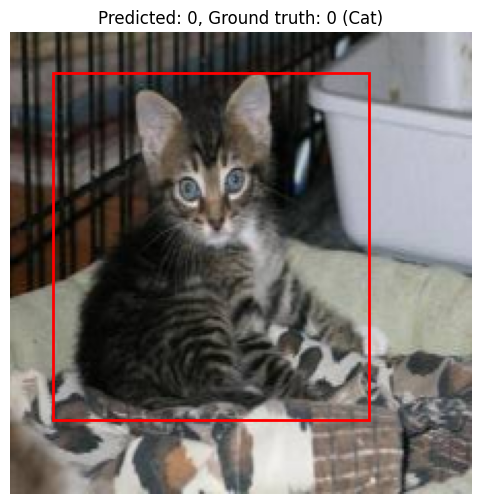

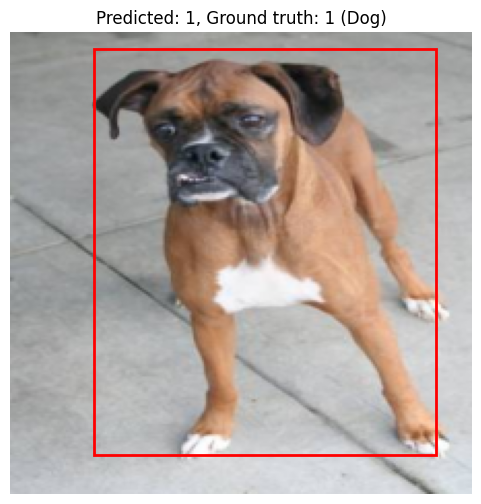

In [30]:
mean = [0.485, 0.456, 0.406]  # Средние значения для нормализации
std = [0.229, 0.224, 0.225]  

def denormalize(image, mean, std):
    for c, (m, s) in enumerate(zip(mean, std)):
        image[c] = image[c] * s + m
    return image

model.to(device)  
model.eval()  

data_iter = iter(train_loader)  # или val_loader
images, targets = next(data_iter)

images = images.to(device)

cat_image = images[targets['label'] == 0][0]  # Первая кошка
dog_image = images[targets['label'] == 1][0]  # Первая собака

with torch.no_grad():
    cat_class_preds, cat_bbox_preds = model(cat_image.unsqueeze(0).to(device))
    dog_class_preds, dog_bbox_preds = model(dog_image.unsqueeze(0).to(device))

cat_class_pred = cat_class_preds.argmax(dim=-1).item()
cat_bbox_pred = cat_bbox_preds.squeeze(0).cpu().numpy()

dog_class_pred = dog_class_preds.argmax(dim=-1).item()
dog_bbox_pred = dog_bbox_preds.squeeze(0).cpu().numpy()

cat_image = denormalize(cat_image.cpu(), mean, std)
dog_image = denormalize(dog_image.cpu(), mean, std)

cat_image = cat_image.permute(1, 2, 0).cpu().numpy()
dog_image = dog_image.permute(1, 2, 0).cpu().numpy()

image_h, image_w = cat_image.shape[:2]

cat_xmin, cat_ymin, cat_xmax, cat_ymax = cat_bbox_pred
cat_xmin, cat_xmax = cat_xmin * image_w, cat_xmax * image_w
cat_ymin, cat_ymax = cat_ymin * image_h, cat_ymax * image_h

image_h, image_w = dog_image.shape[:2]
dog_xmin, dog_ymin, dog_xmax, dog_ymax = dog_bbox_pred
dog_xmin, dog_xmax = dog_xmin * image_w, dog_xmax * image_w
dog_ymin, dog_ymax = dog_ymin * image_h, dog_ymax * image_h

plt.figure(figsize=(6, 6))
plt.imshow(cat_image)  
plt.axis('off')
plt.gca().add_patch(plt.Rectangle((cat_xmin, cat_ymin), cat_xmax - cat_xmin, cat_ymax - cat_ymin, 
                                  linewidth=2, edgecolor='r', facecolor='none'))
plt.title(f"Predicted: {cat_class_pred}, Ground truth: 0 (Cat)")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(dog_image) 
plt.axis('off')
plt.gca().add_patch(plt.Rectangle((dog_xmin, dog_ymin), dog_xmax - dog_xmin, dog_ymax - dog_ymin, 
                                  linewidth=2, edgecolor='r', facecolor='none'))
plt.title(f"Predicted: {dog_class_pred}, Ground truth: 1 (Dog)")
plt.show()


<p class="task" id="3"></p>

3\. Загрузите чекпоинт обученной модели и переведите модель в режим оценки. Допишите функцию `transform_image` и route `predict`. Запустите сервер flask и сделайте POST-запрос к соответствующему эндпоинту. 

При работе в Google Colab вы можете воспользоваться инструментом `ngrok` для проброса локального адреса или запустить сервер Flask в отдельном потоке.

- [ ] Проверено на семинаре

In [18]:
from PIL import Image
import io
from torchvision import transforms
import torch

def bytes_to_pil(image_bytes: bytes) -> Image:
    return Image.open(io.BytesIO(image_bytes))

def transform_image(image: Image) -> torch.Tensor:

    transform = transforms.Compose([
        transforms.Resize((256, 256)), 
        transforms.ToTensor(), 
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
    ])
    
    image_tensor = transform(image)
    return image_tensor


In [19]:
from flask import Flask, request, jsonify
from PIL import Image
import torch
from torchvision import models, transforms
import io
import threading
import pytorch_lightning as pl



CHECKPOINT_PATH = r"C:\Users\nsedoff\PycharmProjects\ITiABD-PM22-7-Nikolay-Sedov\DL\lightning_logs\version_34\checkpoints\best-checkpoint.ckpt"


model = ObjectDetectionModel.load_from_checkpoint(CHECKPOINT_PATH)
model.eval() 


app = Flask(__name__)

ALLOWED_EXTENSIONS = {"png", "jpg", "jpeg"}

def allowed_file(filename):
    return "." in filename and filename.rsplit(".", 1)[1].lower() in ALLOWED_EXTENSIONS

@app.route("/predict", methods=["POST"])
def predict():
    if request.method == "POST":
        file = request.files.get("file")
        if file is None or file.filename == "":
            return jsonify({"error": "no file"})
        if not allowed_file(file.filename):
            return jsonify({"error": "format not supported"})
        
        try:
            img_bytes = file.read()
            image = bytes_to_pil(img_bytes)
            tensor = transform_image(image)


            tensor = tensor.to(model.device)


            with torch.no_grad():
                class_preds, bbox_preds = model(tensor.unsqueeze(0)) 
            
                class_pred = class_preds.argmax(dim=1).item()
            

                bbox_pred = bbox_preds.squeeze(0).cpu().numpy()  


            image_w, image_h = image.size
            xmin, ymin, xmax, ymax = bbox_pred

            xmin = xmin * image_w
            xmax = xmax * image_w
            ymin = ymin * image_h
            ymax = ymax * image_h

            data = {
                "bbox": [xmin, ymin, xmax, ymax],
                "label": class_pred
            }

            return jsonify(data)

        except Exception as e:
            return jsonify({"error": f"error during prediction: {e}"})

if __name__ == "__main__":
    threading.Thread(target=lambda: app.run(debug=True, use_reloader=False)).start()


 * Serving Flask app '__main__'
 * Debug mode: on


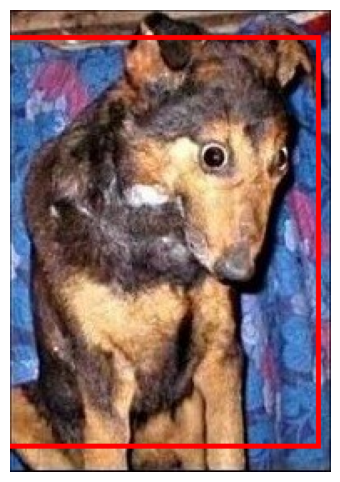

Predicted: Dog


In [71]:
import requests
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

url = "http://127.0.0.1:5000/predict"

image_path = "C:\\Users\\nsedoff\\PycharmProjects\\ITiABD-PM22-7-Nikolay-Sedov\\DL\\lmao_dog2.jpg"

resp = requests.post(
    url,
    files={
        "file": open(image_path, "rb")  
    }
)

if resp.status_code == 200:
    response_data = resp.json()

    bbox = response_data.get("bbox")
    label = response_data.get("label")

    if bbox:
        image = Image.open(image_path)
        image_w, image_h = image.size

        xmin, ymin, xmax, ymax = bbox

        draw = ImageDraw.Draw(image)
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)

        label_text = f"Predicted: {'Cat' if label == 0 else 'Dog'}"

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.show()
        print(label_text)

    else:
        print("Bounding box не был предсказан.")
else:
    print(f"Ошибка при запросе: {resp.status_code}")


## Обратная связь
- [ ] Хочу получить обратную связь по решению